# Single Layer Perceptron

## Time Complexity

## Space Complexity

### Dataset Generation
 We 2 features and 2 classes to predict (blue and red)

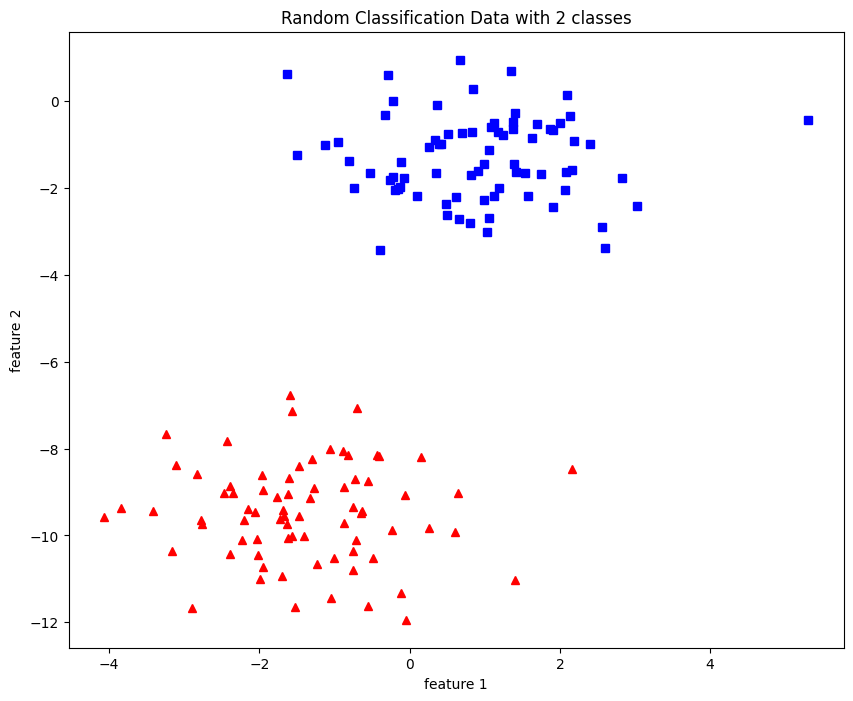

In [29]:
from sklearn import datasets
import matplotlib.pyplot as plt
X, y = datasets.make_blobs (n_samples=150, n_features=2, centers=2, cluster_std=1.05, random_state=2)
#Plotting 
fig = plt.figure(figsize=(10,8))
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], 'r^')
plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], 'bs')
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title('Random Classification Data with 2 classes')
plt.show()

In [30]:
def acti_func(x):
    if x <= 0:
        return 0
    else:
        return 1


In [31]:
import numpy as np

def perceptron(X, y, lr, epochs):

    # m-> number of training examples
    # n-> number of features
    m, n = X.shape

    # Initialisation des poids (bias inclus)
    w = np.zeros((n+1, 1))

    # Liste des erreurs
    n_miss_list = []

    # Training
    for epoch in range(epochs):

        n_miss = 0

        for idx, x_i in enumerate(X):

            # Ajouter bias
            x_i = np.insert(x_i, 0, 1).reshape(-1, 1)

            # Prediction
            y_hat = acti_func(np.dot(x_i.T, w))

            # Si erreur
            if (np.squeeze(y_hat) - y[idx]) != 0:

                # Update weights
                w = w + lr * (y[idx] - y_hat) * x_i

                # Increment miss
                n_miss += 1

        n_miss_list.append(n_miss)

    return w, n_miss_list


In [32]:
w, errors = perceptron(X, y, lr=0.01, epochs=5)

print("weights:")
print(w)

print("errors:")
print(errors)

weights:
[[0.1       ]
 [0.01488595]
 [0.01693843]]
errors:
[14, 0, 0, 0, 0]


In [33]:
def plot_decision_boundary(X, y, w):

    # Plot des points
    plt.scatter(X[y==0][:,0], X[y==0][:,1], color='red', marker='^')
    plt.scatter(X[y==1][:,0], X[y==1][:,1], color='blue', marker='s')

    # Ligne de séparation
    x1 = np.array([min(X[:,0]), max(X[:,0])])

    m = -w[1][0] / w[2][0]
    c = -w[0][0] / w[2][0]

    x2 = m * x1 + c

    plt.plot(x1, x2, 'k-', label="Decision Boundary")

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.legend()

    plt.show()


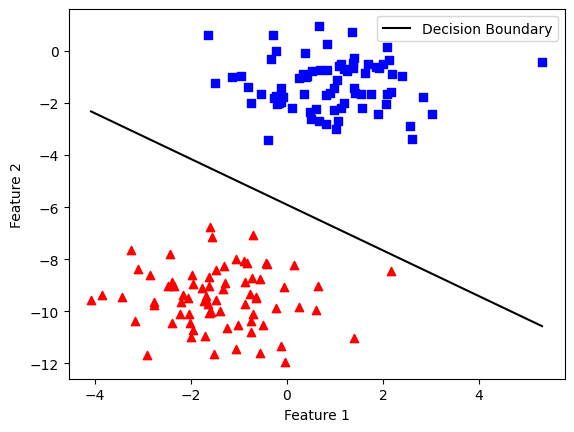

In [34]:
plot_decision_boundary(X,y,w)

In [64]:
import numpy as np
np.random.seed(42)

# paramètres
n = 125
#sigma = 0.5
sigma=np.sqrt(0.1)

mu1 = [-1, 0]
mu2 = [0, 1]

# classe 1
X1 = np.random.normal(mu1, sigma, (n,2))
y1 = np.ones(n)

# classe 0
X2 = np.random.normal(mu2, sigma, (n,2))
y2 = np.zeros(n)

# concat
X7 = np.vstack((X1, X2))
y7 = np.hstack((y1, y2))

In [65]:
w7, errors7 = perceptron(X7, y7, lr=0.01, epochs=100)

print("weights:")
print(w7)

print("errors:")
print(errors7)

weights:
[[-0.01      ]
 [-0.03924717]
 [-0.04082565]]
errors:
[2, 2, 2, 2, 5, 5, 4, 4, 4, 4, 4, 2, 3, 3, 3, 3, 4, 2, 4, 2, 4, 2, 2, 4, 2, 4, 2, 2, 2, 2, 2, 3, 3, 2, 2, 2, 3, 3, 3, 5, 2, 4, 2, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


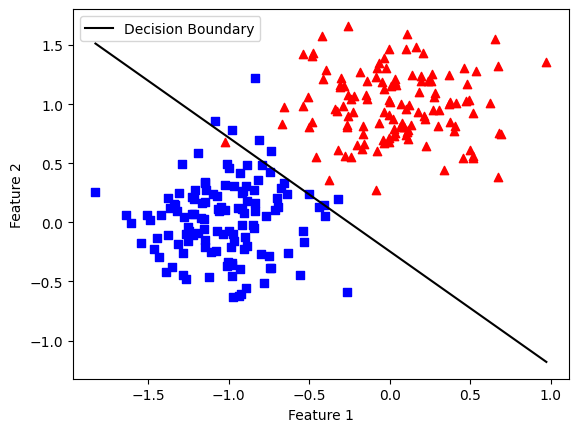

In [63]:
plot_decision_boundary(X7,y7,w7)

In [ ]:
def generate_data(sigma2):

    n = 125

    sigma = np.sqrt(sigma2)

    mu1 = [-1, 0]
    mu2 = [1, 0]

    X1 = np.random.normal(mu1, sigma, (n,2))
    y1 = np.zeros(n)

    X2 = np.random.normal(mu2, sigma, (n,2))
    y2 = np.ones(n)

    X = np.vstack((X1, X2))
    y = np.hstack((y1, y2))

    return shuffle(X, y)
